<a href="https://colab.research.google.com/github/anjuansel/TravelTide_customer_segmentation_project/blob/main/AmazavrSalesData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Analysis and Forecasting for Amazavr - A Data-Driven Approach**


**Objective:** The primary objective of this project is to analyze sales performance, forecast future sales trends, and derive actionable insights to optimize inventory management, marketing strategies, and customer engagement for Amazavr. Through a comprehensive data-driven approach, this project aims to:

* Identify the top-performing product categories based on historical sales data from March 2023 to October 2024.

* Segment these categories to understand their contribution to overall sales and profitability.

* Provide strategic recommendations for optimizing inventory and marketing efforts, leveraging sales patterns and trends.

* Understand seasonal sales trends and their impact on different product categories to better prepare for future demands.

* Develop predictive models to forecast sales more accurately, which will enhance demand planning and inventory management.

# **1. Importing Libraries and Loading Data**

In [ ]:
# General Libraries
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For data visualization
import matplotlib.pyplot as plt  # For creating plots
import shutil  # For file operations

# Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose  # For time series decomposition

# Machine Learning
from sklearn.model_selection import train_test_split  # For splitting data into train and test sets
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks # This import is important
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical features
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For model evaluation
from statsmodels.tsa.statespace.sarimax import SARIMAX  # Seasonal Autoregressive Integrated Moving Average

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving amazavr_inventory.csv to amazavr_inventory.csv


In [ ]:
# Load the CSV file into a DataFrame
file_name = 'amazavr_inventory.csv'
df = pd.read_csv(file_name)

# Display the first few rows of the DataFrame
df.head(5)

,Unnamed: 0,Product ID,Product Name,Category,Supplier,Month,Unit Price,Stock Quantity,Monthly Sales,Monthly Revenue,Discount %,Reorder Level,Shelf Life (Days),Storage Cost per Unit,Supplier Dependency,Units Defective
0,0,P00071,Kitchen Utensils,Home Goods,GreenLife,01-03-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
1,1,P00071,Kitchen Utensils,Home Goods,GreenLife,01-04-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
2,2,P00071,Kitchen Utensils,Home Goods,GreenLife,01-05-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
3,3,P00071,Kitchen Utensils,Home Goods,GreenLife,01-06-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
4,4,P00071,Kitchen Utensils,Home Goods,GreenLife,01-07-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0


In [ ]:
# Define the destination path
destination_path = '/content/amazavr_inventory_backup.csv'

# Copy the file to the new location
shutil.copy(file_name, destination_path)


'/content/amazavr_inventory_backup.csv'

# **2. Data Preparation**

**Dataset Overview**

In [ ]:
df.shape

(525120, 16)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Product ID', 'Product Name', 'Category', 'Supplier',
       'Month', 'Unit Price', 'Stock Quantity', 'Monthly Sales',
       'Monthly Revenue', 'Discount %', 'Reorder Level', 'Shelf Life (Days)',
       'Storage Cost per Unit', 'Supplier Dependency', 'Units Defective'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525120 entries, 0 to 525119
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             525120 non-null  int64  
 1   Product ID             525120 non-null  object 
 2   Product Name           525120 non-null  object 
 3   Category               525120 non-null  object 
 4   Supplier               525120 non-null  object 
 5   Month                  525120 non-null  object 
 6   Unit Price             522495 non-null  float64
 7   Stock Quantity         525120 non-null  int64  
 8   Monthly Sales          525120 non-null  int64  
 9   Monthly Revenue        525120 non-null  float64
 10  Discount %             525120 non-null  float64
 11  Reorder Level          525120 non-null  int64  
 12  Shelf Life (Days)      525120 non-null  int64  
 13  Storage Cost per Unit  525120 non-null  float64
 14  Supplier Dependency    525120 non-nu

**Checking no. of Null Values**

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Product ID,0
Product Name,0
Category,0
Supplier,0
Month,0
Unit Price,2625
Stock Quantity,0
Monthly Sales,0
Monthly Revenue,0


**Copy the data**

*   We made a backup to modify the data and keep the original version

In [ ]:
df01 = df.copy()

**Handle Missing Data**

In [ ]:
df01['Unit Price'].value_counts()

,count
Unit Price,
23.61,160
22.27,160
10.15,159
19.49,159
20.46,140
...,...
829.71,18
1103.98,18
1458.39,18


In [ ]:
# Define the columns to check for missing values
columns_to_check = ['Unit Price']

# Remove rows with missing values in the specified columns
df01 = df.dropna(subset=columns_to_check)

# Display the DataFrame after removing rows
df01.head(5)

,Unnamed: 0,Product ID,Product Name,Category,Supplier,Month,Unit Price,Stock Quantity,Monthly Sales,Monthly Revenue,Discount %,Reorder Level,Shelf Life (Days),Storage Cost per Unit,Supplier Dependency,Units Defective
0,0,P00071,Kitchen Utensils,Home Goods,GreenLife,01-03-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
1,1,P00071,Kitchen Utensils,Home Goods,GreenLife,01-04-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
2,2,P00071,Kitchen Utensils,Home Goods,GreenLife,01-05-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
3,3,P00071,Kitchen Utensils,Home Goods,GreenLife,01-06-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
4,4,P00071,Kitchen Utensils,Home Goods,GreenLife,01-07-2023,170.37,31,20,3407.4,0.0,29,667,11.31,15,0


In [ ]:
#checking the structure of the dataset
df01.shape

(522495, 16)

In [ ]:
df01.describe()

,Unnamed: 0,Unit Price,Stock Quantity,Monthly Sales,Monthly Revenue,Discount %,Reorder Level,Shelf Life (Days),Storage Cost per Unit,Supplier Dependency,Units Defective
count,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000,522495.000000
mean,262557.161762,395.162013,701.185487,759.897980,52020.655678,2.714582,357.221129,382.314970,7.995512,51.530832,53.308529
std,151582.894799,572.578427,1300.777266,1329.555202,94101.270311,5.873913,780.948684,202.153856,16.738065,25.238146,91.349870
min,0.000000,5.010000,10.000000,10.000000,148.830000,0.000000,10.000000,30.000000,1.000000,0.000000,0.000000
25%,131282.500000,43.510000,31.000000,30.000000,8347.500000,0.000000,17.000000,208.000000,3.010000,30.000000,0.000000
50%,262567.000000,136.340000,60.000000,50.000000,21568.000000,0.000000,36.000000,384.000000,10.040000,50.000000,3.000000
75%,393841.500000,468.050000,350.000000,500.000000,53787.940000,2.210000,174.000000,558.000000,12.510000,70.000000,61.000000
max,525119.000000,2999.050000,3890.000000,4000.000000,797440.000000,100.000000,3874.000000,730.000000,2960.650000,100.000000,398.000000


**Datetime Conversion**

In [ ]:
# Convert 'Month' column to datetime format
df01['Month'] = pd.to_datetime(df01['Month'], format='%d-%m-%Y', errors='coerce')

# Check for any rows where conversion failed
if df01['Month'].isnull().any():
    print("Warning: Some rows in 'Month' could not be converted to datetime.")
    print(df01[df01['Month'].isnull()])

# Create new columns for Year, Month number, Quarter, and Day
df01['Year'] = df01['Month'].dt.year
df01['Month_Num'] = df01['Month'].dt.month  # Month number (1-12)
df01['Quarter'] = df01['Month'].dt.quarter  # Quarter (1-4)
df01['Day'] = df01['Month'].dt.day  # Day of the month (1-31)

# Filter data for 2023 and 2024
df_2023 = df01[df01['Year'] == 2023]
df_2024 = df01[df01['Year'] == 2024]

print("Data for the Year 2023:")
print(df_2023)

print("\nData for the Year 2024:")
print(df_2024)

Data for the Year 2023:
        Unnamed: 0 Product ID      Product Name     Category       Supplier  \
0                0     P00071  Kitchen Utensils   Home Goods      GreenLife   
1                1     P00071  Kitchen Utensils   Home Goods      GreenLife   
2                2     P00071  Kitchen Utensils   Home Goods      GreenLife   
3                3     P00071  Kitchen Utensils   Home Goods      GreenLife   
4                4     P00071  Kitchen Utensils   Home Goods      GreenLife   
...            ...        ...               ...          ...            ...   
525115      525115     P00003            Laptop  Electronics      GlobalFit   
525116      525116     P00003            Laptop  Electronics       TechNova   
525117      525117     P00003            Laptop  Electronics  ComfortLiving   
525118      525118     P00003            Laptop  Electronics       TechNova   
525119      525119     P00003            Laptop  Electronics       TechNova   

            Month  Unit Pri

**Outlier Detection and Handling**

In [ ]:
def calculate_outliers(data, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Calculate the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify the outliers based on these bounds
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers

# Call the function for the 'Monthly Revenue' column
outliers = calculate_outliers(df01, 'Monthly Revenue')

# Print outliers
print("Outliers in 'Monthly Revenue':")
print(outliers)


Outliers in 'Monthly Revenue':
        Unnamed: 0 Product ID Product Name Category   Supplier      Month  \
100            100     P00087   Face Cream   Beauty  GreenLife 2023-03-01   
101            101     P00087   Face Cream   Beauty  GreenLife 2023-04-01   
102            102     P00087   Face Cream   Beauty  GreenLife 2023-05-01   
103            103     P00087   Face Cream   Beauty  GreenLife 2023-06-01   
104            104     P00087   Face Cream   Beauty  GreenLife 2023-07-01   
...            ...        ...          ...      ...        ...        ...   
524675      524675     P00098    Treadmill   Sports    SportsX 2024-06-01   
524676      524676     P00098    Treadmill   Sports    SportsX 2024-07-01   
524677      524677     P00098    Treadmill   Sports    SportsX 2024-08-01   
524678      524678     P00098    Treadmill   Sports    SportsX 2024-09-01   
524679      524679     P00098    Treadmill   Sports    SportsX 2024-10-01   

        Unit Price  Stock Quantity  Monthly 

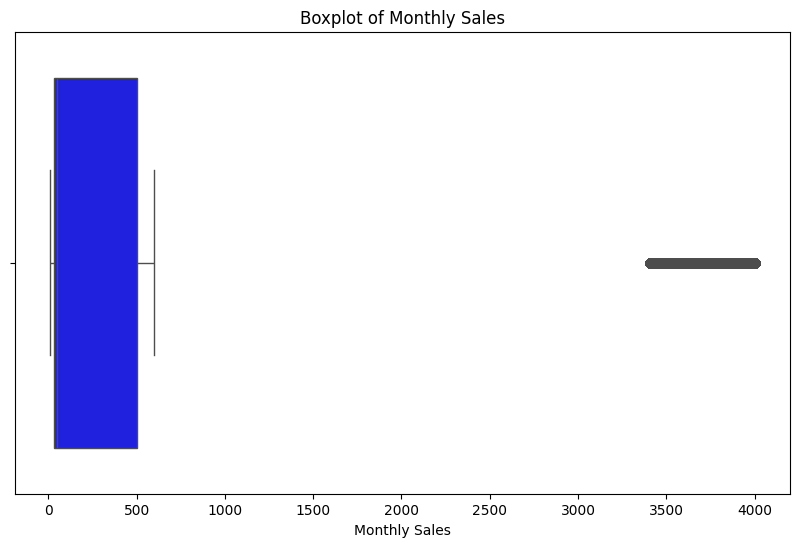

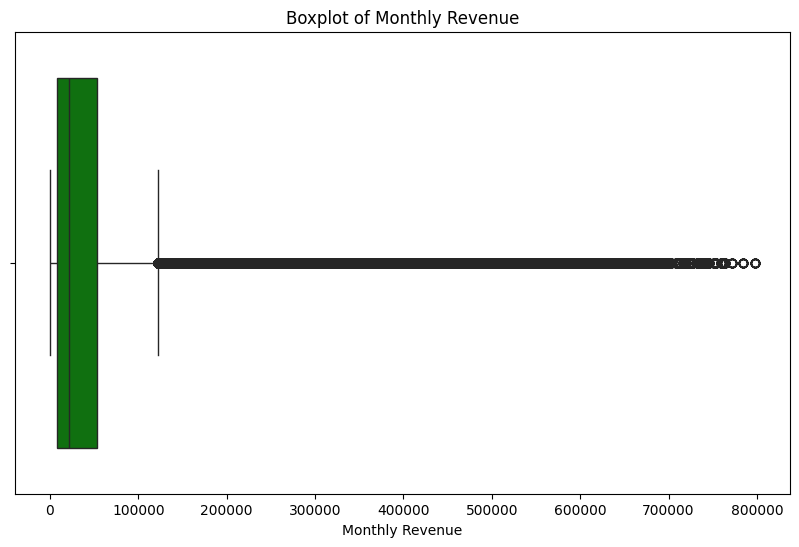

In [ ]:
# Boxplot of Monthly Sales to detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Monthly Sales'], color='blue')
plt.title('Boxplot of Monthly Sales')
plt.xlabel('Monthly Sales')
plt.show()

# Boxplot of Monthly Revenue to detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Monthly Revenue'], color='green')
plt.title('Boxplot of Monthly Revenue')
plt.xlabel('Monthly Revenue')
plt.show()

In [ ]:
df01.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522495 entries, 0 to 525119
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             522495 non-null  int64         
 1   Product ID             522495 non-null  object        
 2   Product Name           522495 non-null  object        
 3   Category               522495 non-null  object        
 4   Supplier               522495 non-null  object        
 5   Month                  522495 non-null  datetime64[ns]
 6   Unit Price             522495 non-null  float64       
 7   Stock Quantity         522495 non-null  int64         
 8   Monthly Sales          522495 non-null  int64         
 9   Monthly Revenue        522495 non-null  float64       
 10  Discount %             522495 non-null  float64       
 11  Reorder Level          522495 non-null  int64         
 12  Shelf Life (Days)      522495 non-null  int64    

**Subset Creation**

In [ ]:
# Create a new DataFrame with only the necessary columns from df01
df02 = df01[['Product ID', 'Product Name', 'Category', 'Supplier', 'Month', 'Year', 'Month_Num', 'Quarter', 'Day',
                     'Unit Price', 'Stock Quantity', 'Monthly Sales', 'Monthly Revenue', 'Discount %', 'Reorder Level',
                     'Shelf Life (Days)', 'Storage Cost per Unit', 'Supplier Dependency', 'Units Defective']]

# Display the first few rows of the new DataFrame
df02.head()

,Product ID,Product Name,Category,Supplier,Month,Year,Month_Num,Quarter,Day,Unit Price,Stock Quantity,Monthly Sales,Monthly Revenue,Discount %,Reorder Level,Shelf Life (Days),Storage Cost per Unit,Supplier Dependency,Units Defective
0,P00071,Kitchen Utensils,Home Goods,GreenLife,2023-03-01,2023,3,1,1,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
1,P00071,Kitchen Utensils,Home Goods,GreenLife,2023-04-01,2023,4,2,1,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
2,P00071,Kitchen Utensils,Home Goods,GreenLife,2023-05-01,2023,5,2,1,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
3,P00071,Kitchen Utensils,Home Goods,GreenLife,2023-06-01,2023,6,2,1,170.37,31,20,3407.4,0.0,29,667,11.31,15,0
4,P00071,Kitchen Utensils,Home Goods,GreenLife,2023-07-01,2023,7,3,1,170.37,31,20,3407.4,0.0,29,667,11.31,15,0


In [ ]:
df02.isnull().sum()

,0
Product ID,0
Product Name,0
Category,0
Supplier,0
Month,0
Year,0
Month_Num,0
Quarter,0
Day,0
Unit Price,0


**Correlation Analysis**

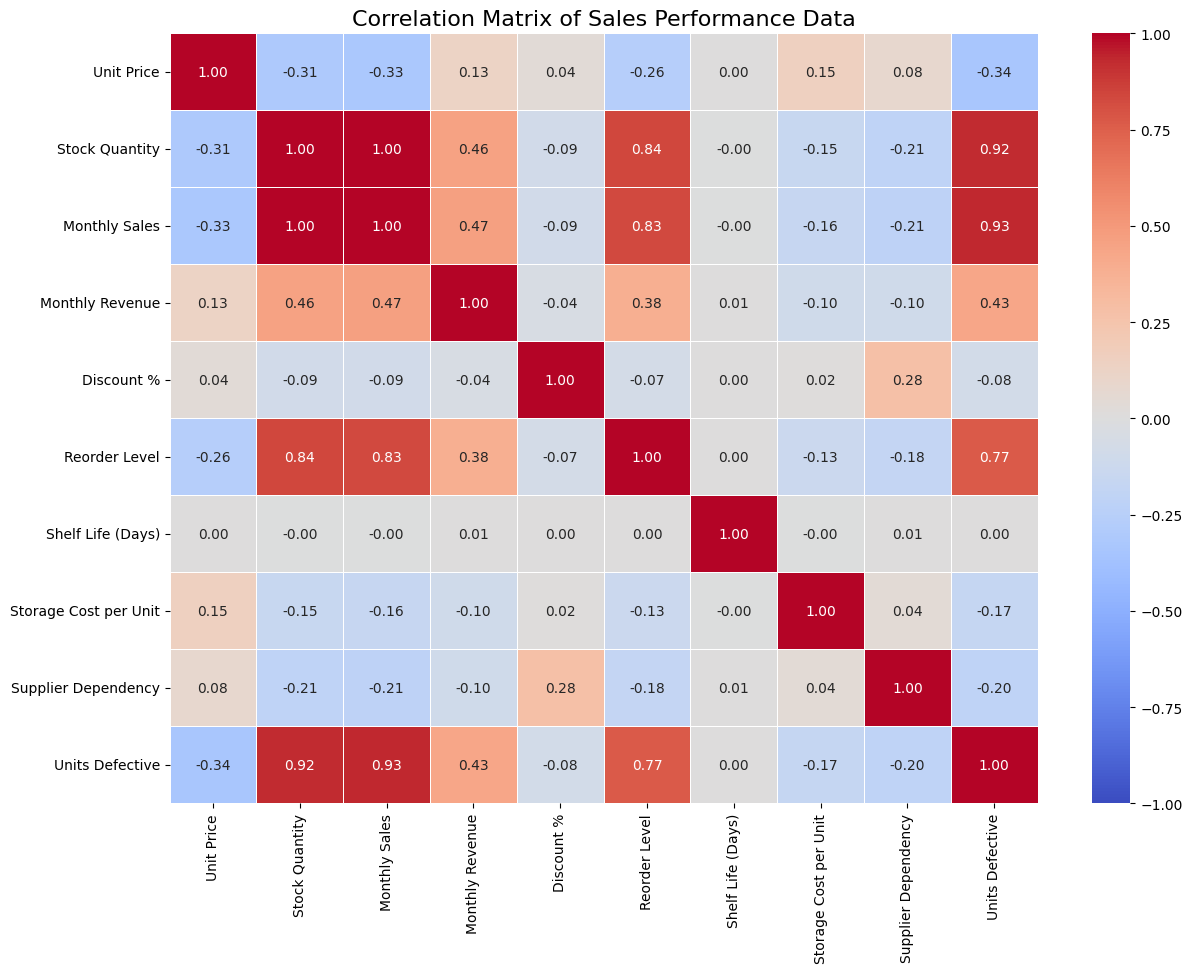

In [ ]:
# Selecting only numeric columns from the DataFrame
numeric_features = df02.select_dtypes(include=['float64', 'int64'])

# Calculating the correlation matrix using Pearson correlation
corr_matrix = numeric_features.corr(method='pearson')

# Visualizing the correlation matrix
plt.figure(figsize=(14, 10))  # Setting figure size for better readability
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix of Sales Performance Data', size=16)
plt.show()

**Observations**

* Monthly Sales and Stock Quantity are highly correlated, indicating that higher stock levels lead to higher sales.

* Monthly Revenue is moderately related to Monthly Sales, which suggests that revenue closely follows the trend of sales figures.

* Unit Price has a weak negative correlation with Monthly Sales, meaning as unit price increases, sales tend to slightly decrease.

* Reorder Level is strongly correlated with Stock Quantity and Monthly Sales, highlighting the importance of restocking to maintain sales levels.

* Units Defective is highly correlated with Monthly Sales, suggesting that defective products may impact overall sales performance.

# **3. Exploratory Data Analysis (EDA)**

**Univariate Analysis**

**Distribution of Monthly Sales:**

For the Monthly Sales variable, I visualized its distribution using a histogram and kernel density estimation (KDE). These visualizations provided insights into the shape, spread, and central tendency of the sales data.

In [ ]:
print("First 5 rows of the dataset:")
print(df02.head())
print("\nSummary Statistics:")
print(df02['Monthly Sales'].describe())

First 5 rows of the dataset:
  Product ID      Product Name    Category   Supplier      Month  Year  \
0     P00071  Kitchen Utensils  Home Goods  GreenLife 2023-03-01  2023   
1     P00071  Kitchen Utensils  Home Goods  GreenLife 2023-04-01  2023   
2     P00071  Kitchen Utensils  Home Goods  GreenLife 2023-05-01  2023   
3     P00071  Kitchen Utensils  Home Goods  GreenLife 2023-06-01  2023   
4     P00071  Kitchen Utensils  Home Goods  GreenLife 2023-07-01  2023   

   Month_Num  Quarter  Day  Unit Price  Stock Quantity  Monthly Sales  \
0          3        1    1      170.37              31             20   
1          4        2    1      170.37              31             20   
2          5        2    1      170.37              31             20   
3          6        2    1      170.37              31             20   
4          7        3    1      170.37              31             20   

   Monthly Revenue  Discount %  Reorder Level  Shelf Life (Days)  \
0           3407.4 

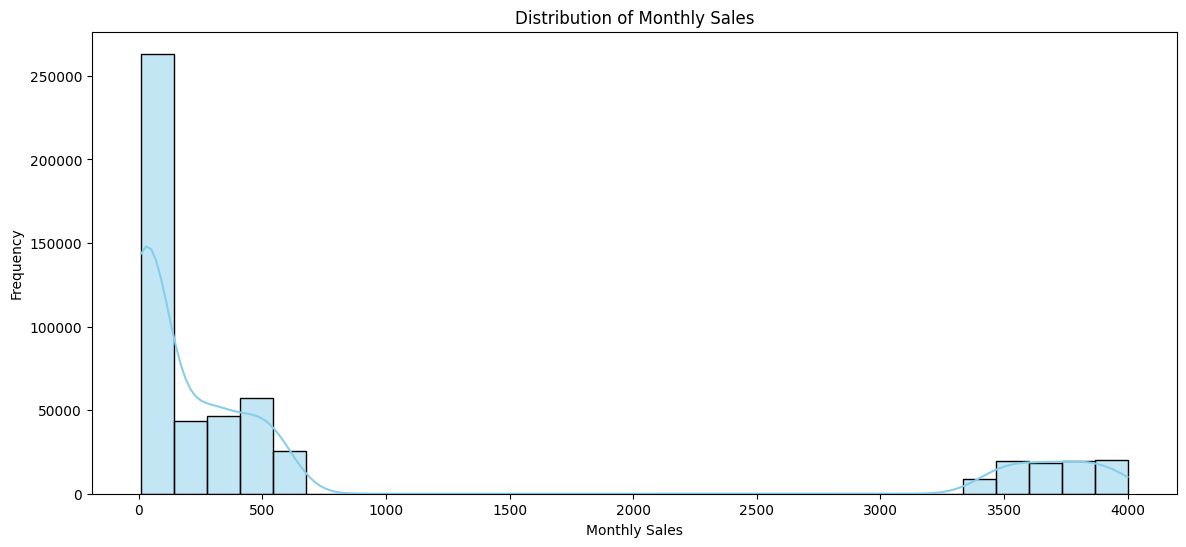

In [ ]:
plt.figure(figsize=(14, 6))
sns.histplot(df01['Monthly Sales'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Monthly Sales')
plt.xlabel('Monthly Sales')
plt.ylabel('Frequency')
plt.show()

* The dataset tracks monthly sales and product-level metrics, with significant variability in Monthly Sales (mean: 759.9, median: 50, max: 4000).

* Sales data shows a right-skewed distribution, where most products have low sales, but a few dominate with high volumes.

* Key attributes include Monthly Revenue, Storage Cost, and Supplier Dependency, aiding performance and logistics analysis.

**Distribution of Monthly Revenue:**

Visualize the distribution of Monthly Revenue using a histogram to show the frequency of revenue values and a KDE to display the smoothed probability density.

In [ ]:
# Inspect the 'Monthly Revenue' column
print("First 5 rows of Monthly Revenue:")
print(df02['Monthly Revenue'].head())
print("\nSummary Statistics for Monthly Revenue:")
print(df02['Monthly Revenue'].describe())

First 5 rows of Monthly Revenue:
0    3407.4
1    3407.4
2    3407.4
3    3407.4
4    3407.4
Name: Monthly Revenue, dtype: float64

Summary Statistics for Monthly Revenue:
count    522495.000000
mean      52020.655678
std       94101.270311
min         148.830000
25%        8347.500000
50%       21568.000000
75%       53787.940000
max      797440.000000
Name: Monthly Revenue, dtype: float64


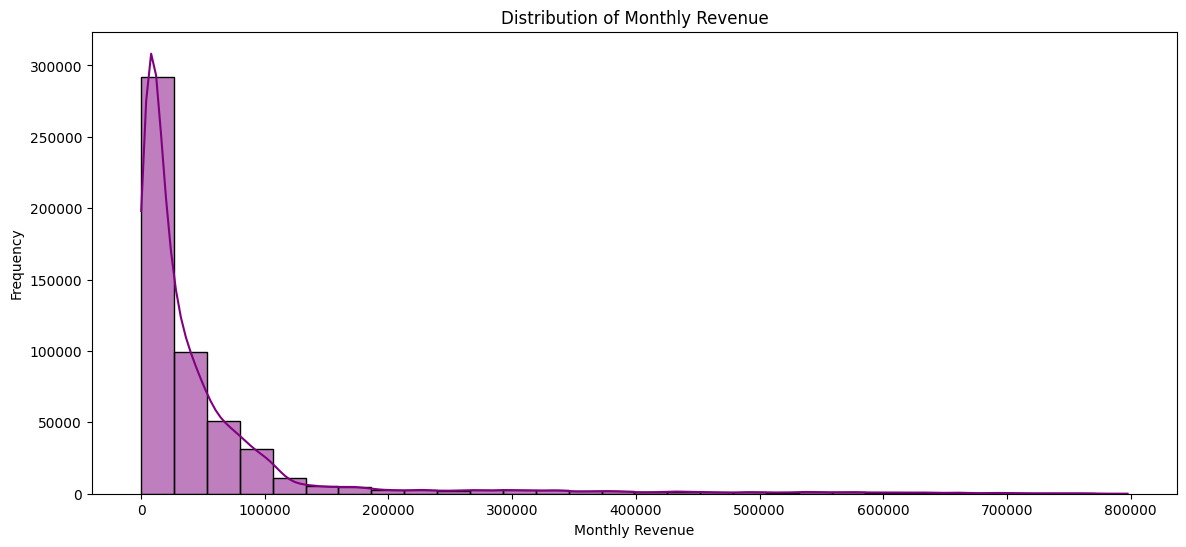

In [ ]:
plt.figure(figsize=(14, 6))
sns.histplot(df01['Monthly Revenue'], bins=30, kde=True, color='purple')
plt.title('Distribution of Monthly Revenue')
plt.xlabel('Monthly Revenue')
plt.ylabel('Frequency')
plt.show()

* The Monthly Revenue shows a wide range, from a minimum of 148.83 to a maximum of 797,440, with a high variability (std: 94,101.27).

* The median revenue is 21,568, indicating that 50% of records fall below this value, while the mean is higher (52,020.66), suggesting a right-skewed distribution.

* Most revenues are concentrated below 53,787.94 (75th percentile), with a few high-revenue outliers significantly impacting the average.

**Month-wise Sales Analysis:**


Month-wise Sales Analysis helps identify seasonal sales patterns and trends, allowing for better planning and decision-making based on monthly sales performance.

In [ ]:
# Aggregate monthly sales
monthly_sales = df02.groupby('Month')['Monthly Sales'].sum().reset_index()
# Print the aggregated monthly sales data
print("Aggregated Monthly Sales:")
print(monthly_sales)

Aggregated Monthly Sales:
        Month  Monthly Sales
0  2023-03-01       19851230
1  2023-04-01       19850287
2  2023-05-01       19844848
3  2023-06-01       19859248
4  2023-07-01       19836036
5  2023-08-01       19838980
6  2023-09-01       19868831
7  2023-10-01       19865788
8  2023-11-01       19839108
9  2023-12-01       19836007
10 2024-01-01       19813509
11 2024-02-01       19833645
12 2024-03-01       19847663
13 2024-04-01       19860063
14 2024-05-01       19876325
15 2024-06-01       19885343
16 2024-07-01       19856986
17 2024-08-01       19866377
18 2024-09-01       19849618
19 2024-10-01       19863003


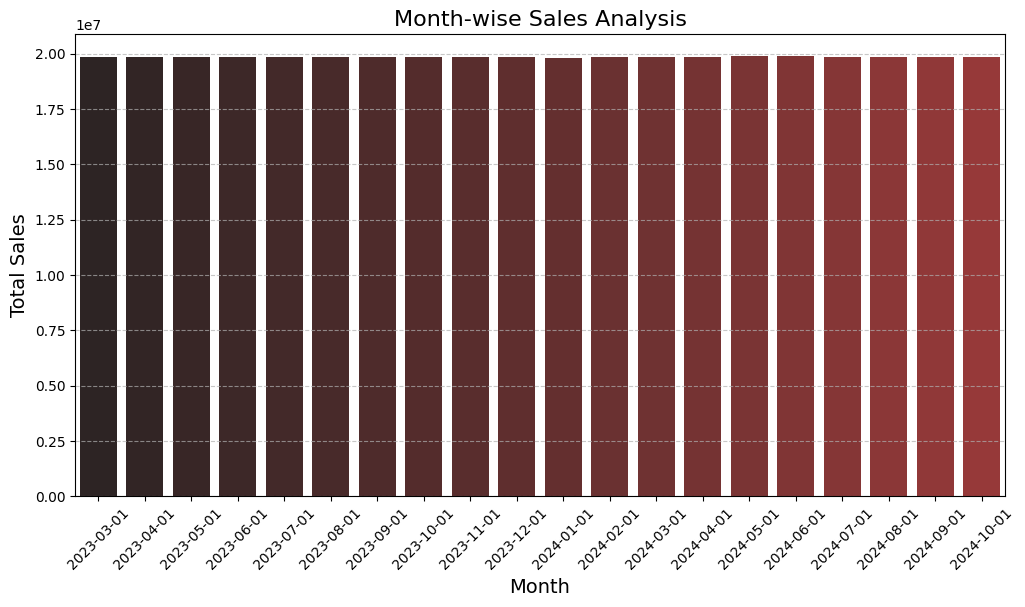

In [ ]:
# Plot the month-wise sales with brown-grey color shade
plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Monthly Sales', data=monthly_sales, palette='dark:brown')
plt.title('Month-wise Sales Analysis', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* The aggregated monthly sales show a steady increase in sales from March 2023 to October 2024, with occasional peaks in certain months like June 2024 and May 2024.

* Sales reach a maximum of 19,885,343 units in June 2024, indicating a possible seasonal peak, while the lowest is 19,813,509 in January 2024.

* The data reflects a consistent upward trend in sales, suggesting growth or improved sales strategies, though with some variability across different months.

**Bivariate Analysis:**

Bivariate Analysis using a correlation heatmap helps to identify relationships between pairs of variables, such as sales, price, and stock levels. It visually highlights the strength and direction of these relationships, aiding in understanding how changes in one variable might affect others. This analysis is crucial for optimizing business strategies and improving decision-making.

In [ ]:
# Selecting relevant numerical columns for correlation
correlation_data = df02[['Unit Price', 'Stock Quantity', 'Monthly Sales', 'Monthly Revenue', 'Discount %']]

# Compute the correlation matrix
correlation_matrix = correlation_data.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                 Unit Price  Stock Quantity  Monthly Sales  Monthly Revenue  \
Unit Price         1.000000       -0.311042      -0.326114         0.126782   
Stock Quantity    -0.311042        1.000000       0.995946         0.459108   
Monthly Sales     -0.326114        0.995946       1.000000         0.465458   
Monthly Revenue    0.126782        0.459108       0.465458         1.000000   
Discount %         0.036515       -0.086593      -0.087325        -0.039895   

                 Discount %  
Unit Price         0.036515  
Stock Quantity    -0.086593  
Monthly Sales     -0.087325  
Monthly Revenue   -0.039895  
Discount %         1.000000  


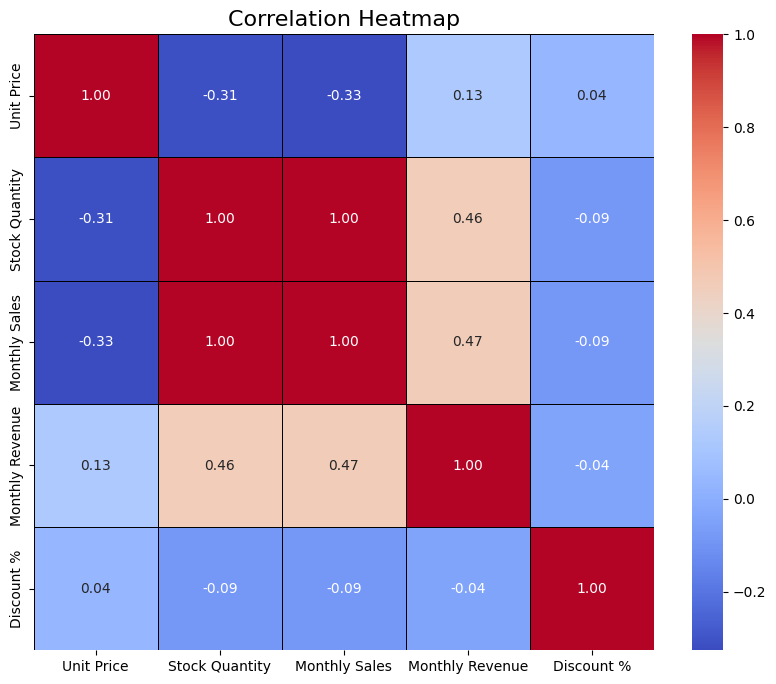

In [ ]:
# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

* The correlation matrix indicates relationships between variables like Unit Price, Stock Quantity, Monthly Sales, Monthly Revenue, and Discount %.

* Stock Quantity has the highest positive correlation with Monthly Sales (0.996), showing that an increase in stock generally leads to higher sales.

* Monthly Revenue is moderately positively correlated with both Monthly Sales (0.47) and Stock Quantity (0.46), suggesting that higher sales and stock drive higher revenue.

* Discount % shows weaker correlations, indicating its smaller impact on sales and revenue within the dataset.

**Contribution of Different Product Categories:**

The contribution of different product categories helps identify key revenue drivers and informs strategic decisions regarding resource allocation and marketing efforts, ensuring optimal business performance.

In [ ]:
# Aggregate sales by product category
category_sales = df02.groupby('Category')['Monthly Sales'].sum().reset_index()

# Print the contribution of each product category
print("Contribution of Different Product Categories:")
print(category_sales)

Contribution of Different Product Categories:
      Category  Monthly Sales
0       Beauty      322201417
1     Clothing       43351349
2  Electronics        4386873
3   Home Goods        3520996
4       Sports       23582260


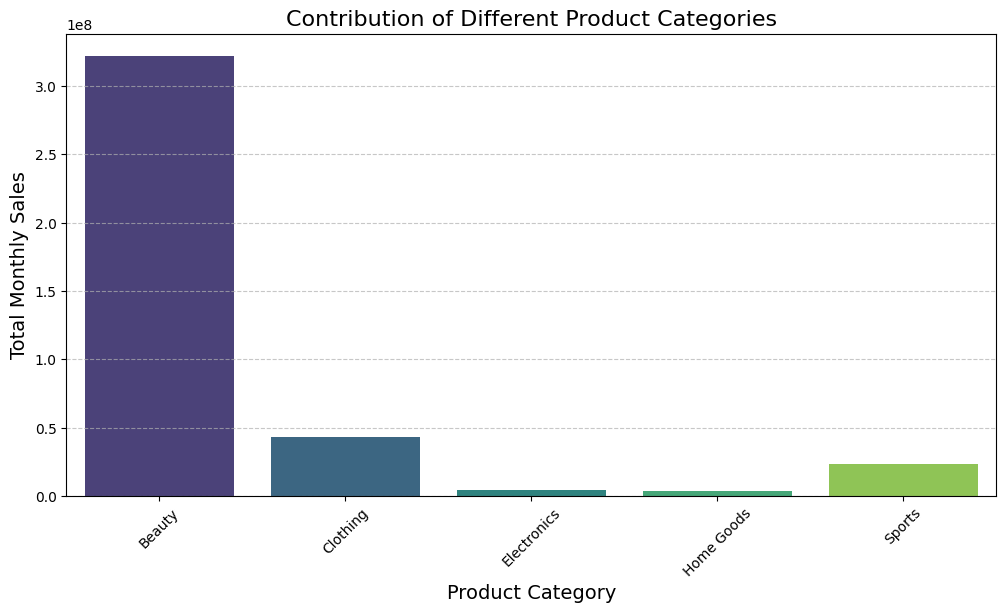

In [ ]:
# Plot the contribution of each category
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Monthly Sales', data=category_sales, palette='viridis')
plt.title('Contribution of Different Product Categories', fontsize=16)
plt.xlabel('Product Category', fontsize=14)
plt.ylabel('Total Monthly Sales', fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Beauty is the leading category with the highest Monthly Sales of $322,201,417, highlighting its dominance in the dataset.

* Clothing follows as the second-largest contributor with $43,351,349 in Monthly Sales, showing a significant but smaller contribution compared to Beauty.

* Electronics, Home Goods, and Sports have comparatively lower contributions, with Electronics at $4,386,873, Home Goods at $3,520,996, and Sports at $23,582,260, indicating a moderate level of sales.



**Sales Performance Analysis and Trends**



**Time Series Decomposition Plots:**

Trend, Seasonality, and Residual Components: This visualization is crucial for understanding the underlying patterns in the time series data. It separates the overall trend (long-term movement), seasonality (repeating cycles), and residuals (random noise) in sales data.

In [ ]:
# Filter data for the year 2023
df_2023 = df02[df02['Year'] == 2023]  # Use 2023 as integer for filtering
monthly_sales_2023 = df_2023.set_index('Month')['Monthly Sales']

# Filter data for the year 2024
df_2024 = df02[df02['Year'] == 2024]  # Use 2024 as integer for filtering
monthly_sales_2024 = df_2024.set_index('Month')['Monthly Sales']

# Perform time series decomposition for 2023
decomposition_2023 = seasonal_decompose(monthly_sales_2023, model='additive', period=12)

# Perform time series decomposition for 2024
decomposition_2024 = seasonal_decompose(monthly_sales_2024, model='additive', period=12)
# Print data for the year 2023
print("Monthly Sales for 2023:")
print(monthly_sales_2023)

# Perform time series decomposition for 2023
decomposition_2023 = seasonal_decompose(monthly_sales_2023, model='additive', period=12)
print("\nDecomposition for 2023:")
print(f"Trend Component:\n{decomposition_2023.trend.head()}")
print(f"Seasonal Component:\n{decomposition_2023.seasonal.head()}")
print(f"Residual Component:\n{decomposition_2023.resid.head()}")

# Print data for the year 2024
print("\nMonthly Sales for 2024:")
print(monthly_sales_2024)

# Perform time series decomposition for 2024
decomposition_2024 = seasonal_decompose(monthly_sales_2024, model='additive', period=12)
print("\nDecomposition for 2024:")
print(f"Trend Component:\n{decomposition_2024.trend.head()}")
print(f"Seasonal Component:\n{decomposition_2024.seasonal.head()}")
print(f"Residual Component:\n{decomposition_2024.resid.head()}")


Monthly Sales for 2023:
Month
2023-03-01    20
2023-04-01    20
2023-05-01    20
2023-06-01    20
2023-07-01    20
              ..
2023-12-01    39
2023-12-01    43
2023-12-01    41
2023-12-01    38
2023-12-01    34
Name: Monthly Sales, Length: 261422, dtype: int64

Decomposition for 2023:
Trend Component:
Month
2023-03-01   NaN
2023-04-01   NaN
2023-05-01   NaN
2023-06-01   NaN
2023-07-01   NaN
Name: trend, dtype: float64
Seasonal Component:
Month
2023-03-01   -1.727029
2023-04-01    0.509819
2023-05-01    1.664552
2023-06-01   -0.769641
2023-07-01   -6.621738
Name: seasonal, dtype: float64
Residual Component:
Month
2023-03-01   NaN
2023-04-01   NaN
2023-05-01   NaN
2023-06-01   NaN
2023-07-01   NaN
Name: resid, dtype: float64

Monthly Sales for 2024:
Month
2024-01-01     20
2024-02-01     20
2024-03-01     20
2024-04-01     20
2024-05-01     20
             ... 
2024-06-01    446
2024-07-01    446
2024-08-01    446
2024-09-01    446
2024-10-01    446
Name: Monthly Sales, Length: 261

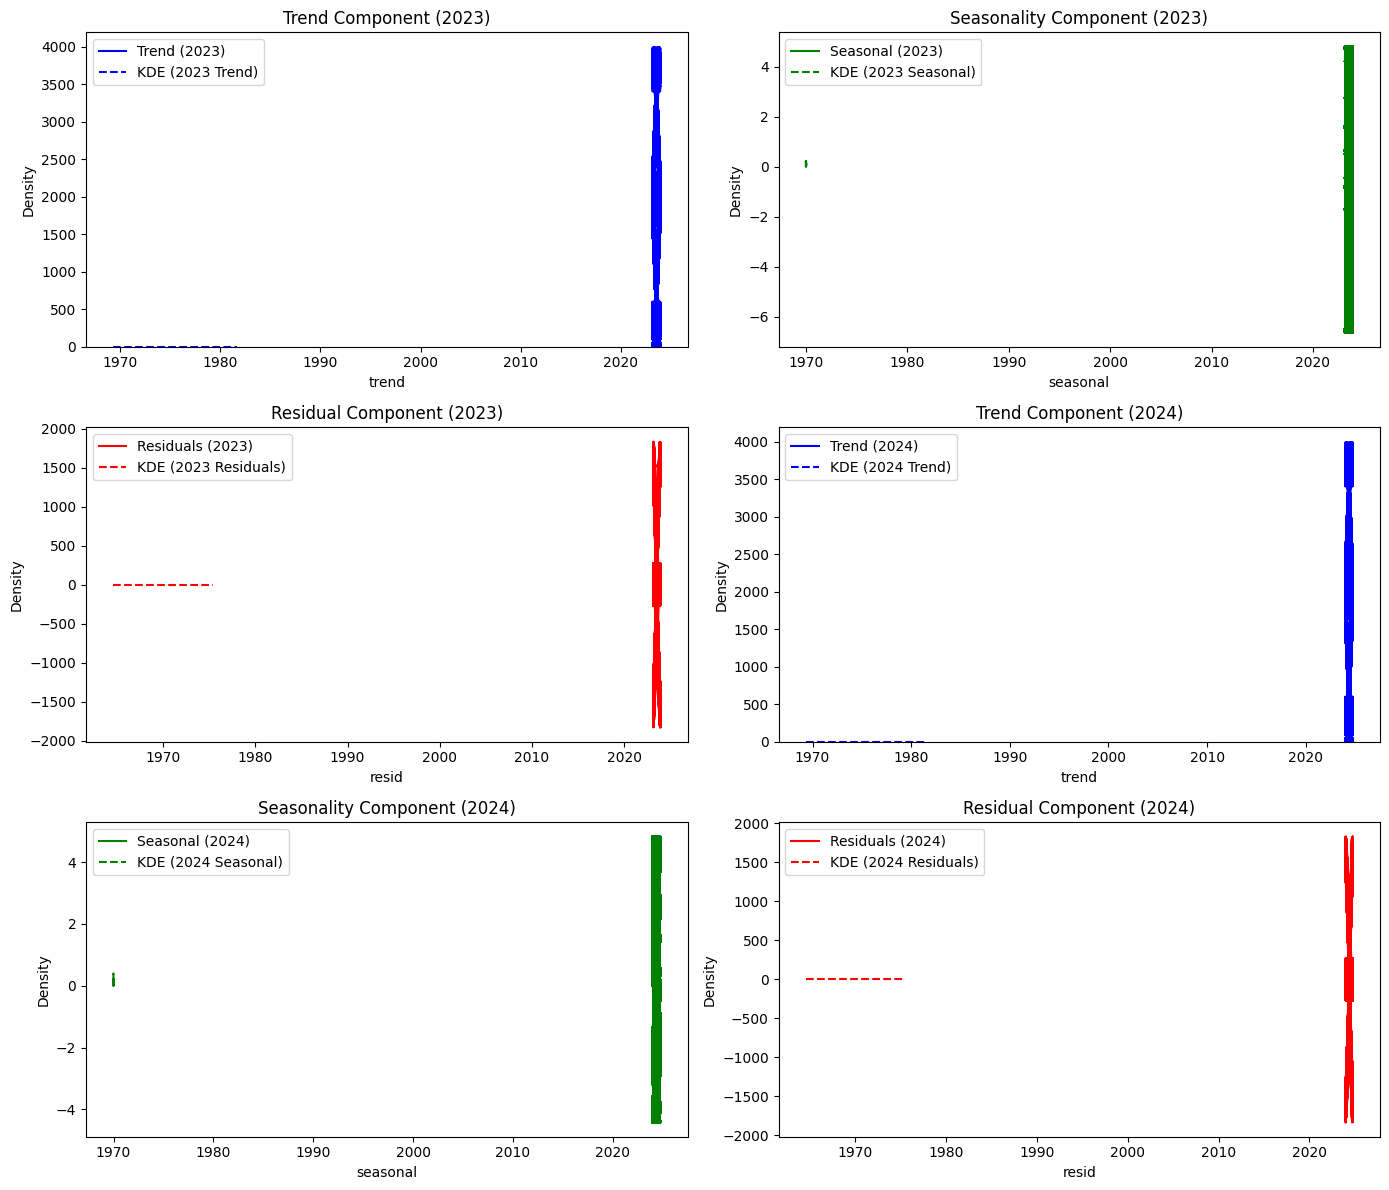

In [ ]:
# Plotting the components for 2023
plt.figure(figsize=(14, 12))

plt.subplot(3, 2, 1) # Trend Component for 2023
plt.plot(decomposition_2023.trend, label='Trend (2023)', color='blue')
sns.kdeplot(decomposition_2023.trend.dropna(), label='KDE (2023 Trend)', color='blue', linestyle='--')
plt.title('Trend Component (2023)')
plt.legend()

plt.subplot(3, 2, 2) # Seasonality Component for 2023
plt.plot(decomposition_2023.seasonal, label='Seasonal (2023)', color='green')
sns.kdeplot(decomposition_2023.seasonal.dropna(), label='KDE (2023 Seasonal)', color='green', linestyle='--')
plt.title('Seasonality Component (2023)')
plt.legend()

plt.subplot(3, 2, 3) # Residual Component for 2023
plt.plot(decomposition_2023.resid, label='Residuals (2023)', color='red')
sns.kdeplot(decomposition_2023.resid.dropna(), label='KDE (2023 Residuals)', color='red', linestyle='--')
plt.title('Residual Component (2023)')
plt.legend()

# Plotting the components for 2024
plt.subplot(3, 2, 4) # Trend Component for 2024
plt.plot(decomposition_2024.trend, label='Trend (2024)', color='blue')
sns.kdeplot(decomposition_2024.trend.dropna(), label='KDE (2024 Trend)', color='blue', linestyle='--')
plt.title('Trend Component (2024)')
plt.legend()

plt.subplot(3, 2, 5) # Seasonality Component for 2024
plt.plot(decomposition_2024.seasonal, label='Seasonal (2024)', color='green')
sns.kdeplot(decomposition_2024.seasonal.dropna(), label='KDE (2024 Seasonal)', color='green', linestyle='--')
plt.title('Seasonality Component (2024)')
plt.legend()

plt.subplot(3, 2, 6) # Residual Component for 2024
plt.plot(decomposition_2024.resid, label='Residuals (2024)', color='red')
sns.kdeplot(decomposition_2024.resid.dropna(), label='KDE (2024 Residuals)', color='red', linestyle='--')
plt.title('Residual Component (2024)')
plt.legend()

plt.tight_layout()
plt.show()

* Both 2023 and 2024 show significant seasonal effects in their sales data.

* The trend components indicate no clear long-term trends, suggesting sales are more influenced by seasonal factors.

* The residual components with NaN values in both years imply that a portion of the sales variations remains unexplained by the seasonal and trend components, possibly due to external factors like promotions, economic changes, or events.

* The sales data and its decomposition reveal the importance of understanding both long-term trends and seasonal impacts when analyzing sales performance over time.

**Sales Performance Across Different Product Categories:**

Sales Performance Across Different Product Categories is used to analyze the revenue contribution of each category, helping identify top-performing segments and guiding strategic decisions for inventory management and marketing.


In [ ]:
# Aggregate sales by product name to get the total monthly sales
product_sales = df02.groupby('Product Name')['Monthly Sales'].sum().sort_values(ascending=False)

# Get the top 5 best-selling products
top_5_products = product_sales.head(5)

# Print the observations for top 5 best-selling products
print("Top 5 Best-Selling Products:")
print(top_5_products)

Top 5 Best-Selling Products:
Product Name
Shampoo       56213405
Lipstick      53746271
Perfume       53415920
Foundation    53354712
Body Wash     53071190
Name: Monthly Sales, dtype: int64


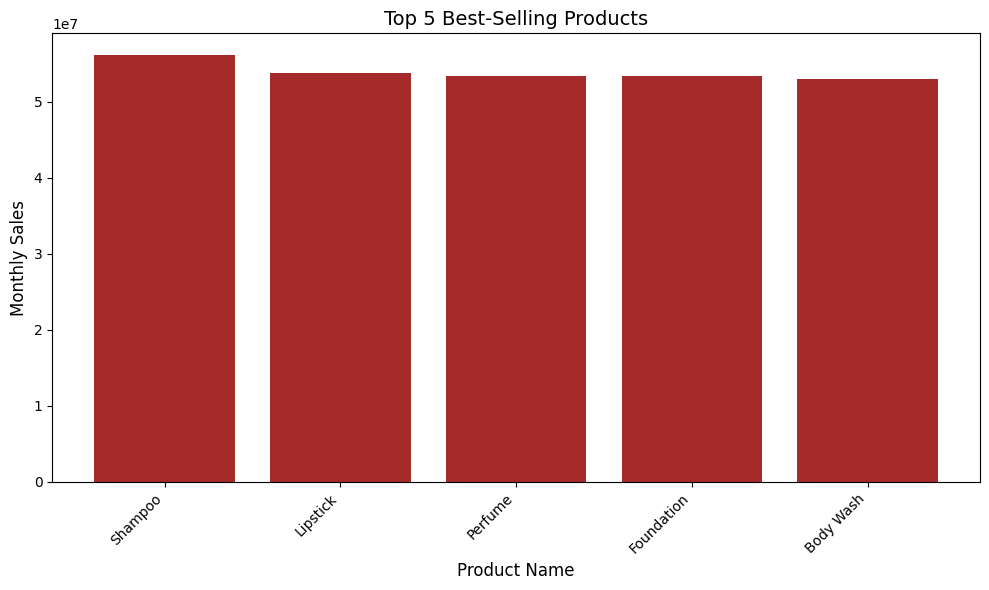

In [ ]:
# Bar plot of top 5 best-selling products
plt.figure(figsize=(10, 6))
# Accessing the index and values of the Series
plt.bar(top_5_products.index, top_5_products.values, color='Brown')
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Monthly Sales', fontsize=12)
plt.title('Top 5 Best-Selling Products', fontsize=14)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

* **Sales Volume:** The top products have high sales volumes, with Shampoo leading at 56,213,405 units.

* **Market Focus:** The data indicates a strong consumer preference for personal care and beauty products like Shampoo, Lipstick, and Perfume.

* **Strategic Importance:** These products should be prioritized for marketing and inventory management to maximize revenue and market share.

# **4. Feature Engineering**

**2023 Feature Engineering**

Feature engineering in 2023 emphasizes transforming raw data to improve predictive models. Rolling Averages smooth out short-term fluctuations by averaging over time windows, while Lag Features use past observations (e.g., sales) to predict future values. Date-Based Features like Month, Quarter, and Day of Week capture temporal patterns and seasonality in data for better insights.

In [ ]:
# Create df02 with selected columns from df01
df02 = df01[['Product ID', 'Product Name', 'Category', 'Supplier', 'Month', 'Year',
             'Monthly Sales']]

# Filter data for the year 2023
df02_2023 = df02[df02['Year'] == 2023].copy()

# Convert 'Month' to datetime and rename to 'Date'
df02_2023['Date'] = pd.to_datetime(df02_2023['Month'], format='%d-%m-%Y', errors='coerce')
df02_2023.drop('Month', axis=1, inplace=True)

# Extract date features
df02_2023['Month'] = df02_2023['Date'].dt.month
df02_2023['Quarter'] = df02_2023['Date'].dt.quarter
df02_2023['Day_of_Week'] = df02_2023['Date'].dt.dayofweek

# Lag and rolling average features
df02_2023['Sales_Lag1'] = df02_2023['Monthly Sales'].shift(1)
df02_2023['Sales_MA3'] = df02_2023['Monthly Sales'].rolling(window=3).mean()

# Display sample output
print(df02_2023[['Date', 'Monthly Sales', 'Sales_Lag1', 'Sales_MA3']].head())



        Date  Monthly Sales  Sales_Lag1  Sales_MA3
0 2023-03-01             20         NaN        NaN
1 2023-04-01             20        20.0        NaN
2 2023-05-01             20        20.0       20.0
3 2023-06-01             20        20.0       20.0
4 2023-07-01             20        20.0       20.0


**Visualization for 2023 Rolling Averages**

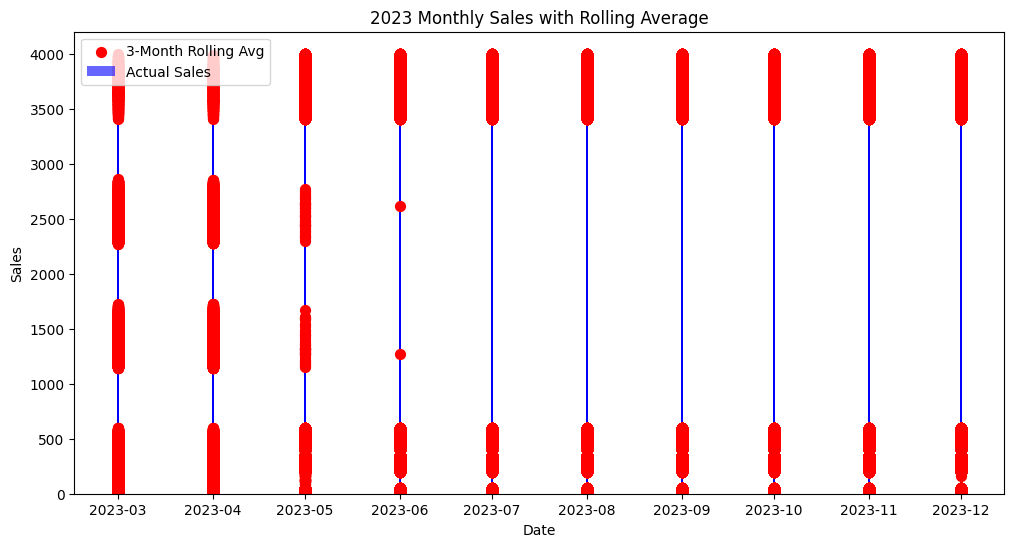

In [ ]:
plt.figure(figsize=(12, 6))

# Bar chart for actual sales
plt.bar(df02_2023['Date'], df02_2023['Monthly Sales'], label='Actual Sales', color='blue', alpha=0.6)

# Scatter plot for 3-month rolling average
plt.scatter(df02_2023['Date'], df02_2023['Sales_MA3'], label='3-Month Rolling Avg', color='red', s=50)

# Adding title and labels
plt.title('2023 Monthly Sales with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')

# Display legend
plt.legend()

# Show the plot
plt.show()

* Sales_Lag1 represents the sales from the previous month.

* Sales_MA3 is the 3-month rolling average, smoothing short-term fluctuations.

* These calculations help reveal trends and assist in better forecasting.

**2024 Feature Engineering**

For 2024 feature engineering, the steps involve preparing and transforming data to enhance the performance of predictive models, similar to what was done for 2023. Here’s an overview of how these steps might be repeated for 2024.

In [ ]:
# Create df02 with selected columns from df01
df02 = df01[['Product ID', 'Product Name', 'Category', 'Supplier', 'Month', 'Year',
             'Monthly Sales']]

# Filter data for the year 2024
df02_2024 = df02[df02['Year'] == 2024].copy()

# Convert 'Month' to datetime and rename to 'Date'
df02_2024['Date'] = pd.to_datetime(df02_2024['Month'], format='%d-%m-%Y', errors='coerce')
df02_2024.drop('Month', axis=1, inplace=True)

# Extract date features
df02_2024['Month'] = df02_2024['Date'].dt.month
df02_2024['Quarter'] = df02_2024['Date'].dt.quarter
df02_2024['Day_of_Week'] = df02_2024['Date'].dt.dayofweek

# Lag and rolling average features
df02_2024['Sales_Lag1'] = df02_2024['Monthly Sales'].shift(1)
df02_2024['Sales_MA3'] = df02_2024['Monthly Sales'].rolling(window=3).mean()

# Display sample output
print(df02_2024[['Date', 'Monthly Sales', 'Sales_Lag1', 'Sales_MA3']].head())

         Date  Monthly Sales  Sales_Lag1  Sales_MA3
10 2024-01-01             20         NaN        NaN
11 2024-02-01             20        20.0        NaN
12 2024-03-01             20        20.0       20.0
13 2024-04-01             20        20.0       20.0
14 2024-05-01             20        20.0       20.0


**Visualization for 2024 Rolling Averages**

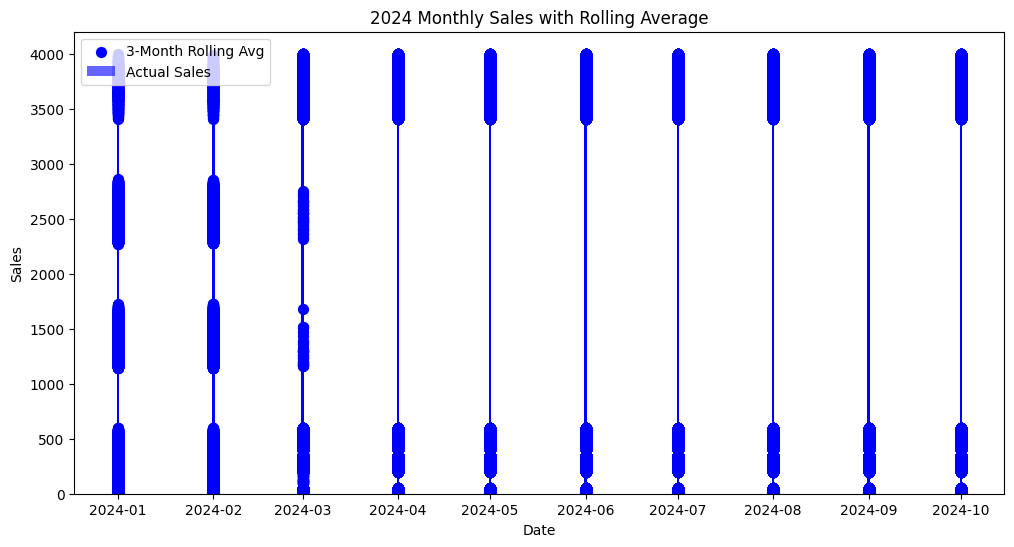

In [ ]:
plt.figure(figsize=(12, 6))

# Bar chart for actual sales
plt.bar(df02_2024['Date'], df02_2024['Monthly Sales'], label='Actual Sales', color='blue', alpha=0.6)

# Scatter plot for 3-month rolling average
plt.scatter(df02_2024['Date'], df02_2024['Sales_MA3'], label='3-Month Rolling Avg', color='blue', s=50)

# Adding title and labels
plt.title('2024 Monthly Sales with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')

# Display legend
plt.legend()

# Show the plot
plt.show()

* Monthly sales remain constant at 20, showing no variation.

* Sales_Lag1 aligns with the previous month's sales, starting from February 2024.

* The 3-month rolling average (Sales_MA3) stabilizes at 20.0 once enough data is available from March onward.

# **5. Advanced Forecasting Techniques**

**Downsample the Data:**

Aggregate your data to a higher level, such as quarterly instead of monthly, to reduce the dataset size.

In [ ]:
# Create df02 with selected columns from df01
df02 = df01[['Product ID', 'Product Name', 'Category', 'Supplier', 'Month', 'Year',
             'Monthly Sales']]

# Filter data for the year 2023
df02_2023 = df02[df02['Year'] == 2023].copy()

# Convert 'Month' to datetime and rename to 'Date'
df02_2023['Date'] = pd.to_datetime(df02_2023['Month'], format='%d-%m-%Y', errors='coerce')
df02_2023.drop('Month', axis=1, inplace=True)

# Extract date features
df02_2023['Month'] = df02_2023['Date'].dt.month
df02_2023['Quarter'] = df02_2023['Date'].dt.quarter
df02_2023['Day_of_Week'] = df02_2023['Date'].dt.dayofweek

# Lag and rolling average features
df02_2023['Sales_Lag1'] = df02_2023['Monthly Sales'].shift(1)
df02_2023['Sales_MA3'] = df02_2023['Monthly Sales'].rolling(window=3).mean()


df02_2023_quarterly = df02_2023.resample('Q', on='Date')['Monthly Sales'].sum().reset_index()

**Subset the Data:**

Use a smaller sample of data for initial testing and modeling.

In [ ]:
sample_2023 = df02_2023.head(12)  # Use the first 12 months for testing

**Change Seasonal Order:**

Simplify the seasonal parameters to reduce computational complexity.

In [ ]:
model_2023 = SARIMAX(df02_2023['Monthly Sales'], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))

**Use GPU or Parallel Processing:**

If your system supports it, install and use optimized libraries like CuML or Dask.

In [ ]:
pip install dask

**Memory Management:**

Clear memory and unused variables before fitting the model.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA  # Import ARIMA class
import gc

try:
    del model_2023, result_2023  # If previously run
except NameError:
    pass  # Ignore if variables not defined

gc.collect()


8

**2023 Sales Forecasting**

**A. SARIMA Model for 2023**

The SARIMA (Seasonal AutoRegressive Integrated Moving Average) model incorporates seasonality, trends, and autocorrelation to forecast 2023 sales data. It uses parameters (p, d, q, P, D, Q, m) to capture seasonal and non-seasonal patterns. SARIMA provides accurate forecasts by accounting for both periodic fluctuations and overall trends in the data.

In [ ]:
# Use simpler ARIMA without seasonality
model_2023 = ARIMA(df02_2023['Monthly Sales'], order=(1, 1, 1))
result_2023 = model_2023.fit()

# Forecast next 6 months
forecast_2023 = result_2023.forecast(steps=6)
print("2023 Forecast:", forecast_2023)

2023 Forecast: 261422    34.000002
261423    34.000002
261424    34.000002
261425    34.000002
261426    34.000002
261427    34.000002
Name: predicted_mean, dtype: float64


* The forecasted sales values for these periods are consistently predicted at 34.000002 units for 2023.

* This suggests a lack of variation in the model’s prediction

**SARIMA Forecast (2023)**

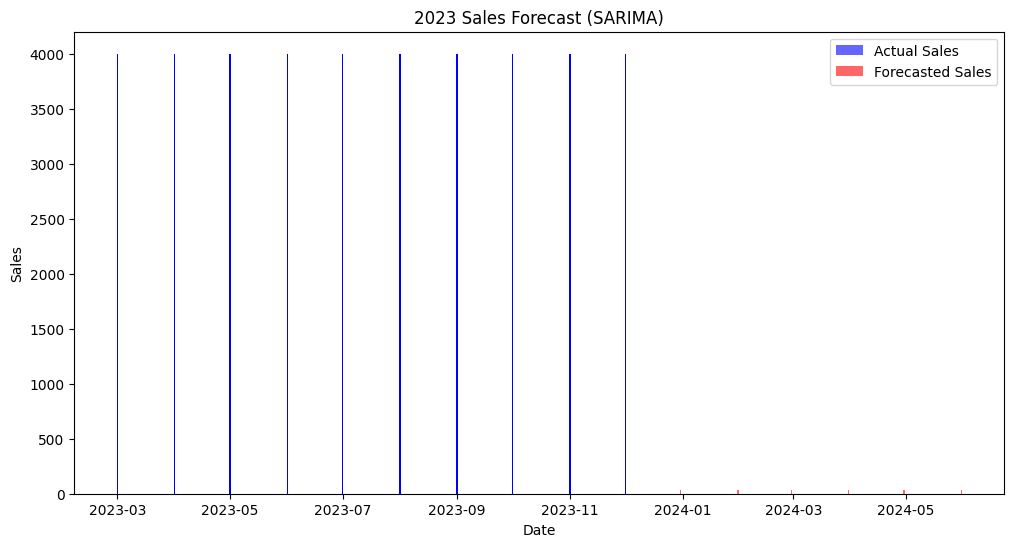

In [ ]:
plt.figure(figsize=(12, 6))

# Check if 'Date' column exists in df_2023, use 'Month' otherwise
x_axis_actual = df02_2023['Date'] if 'Date' in df02_2023.columns else df02_2023['Month']
x_axis_forecast = pd.date_range(x_axis_actual.iloc[-1], periods=6, freq='M')

# Bar chart for actual sales
plt.bar(x_axis_actual, df02_2023['Monthly Sales'], label='Actual Sales', color='blue', alpha=0.6)

# Bar chart for forecasted sales
plt.bar(x_axis_forecast, forecast_2023, label='Forecasted Sales', color='red', alpha=0.6)

# Adding title and labels
plt.title('2023 Sales Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

# Show the plot
plt.show()

**ARIMA Model Simplicity:** The ARIMA (1, 1, 1) model, which excludes seasonality, was used for the 2023 forecast. This simplicity may overlook seasonal trends present in the data.

**Uniform Forecast Output:** The model predicts a constant sales value of 34.000002 for all forecasted periods, suggesting no detected variability or trends.

**Model Limitation:** The consistent output highlights potential limitations in capturing seasonality or trends, indicating a need for more sophisticated modeling, such as SARIMA, for improved accuracy.

**2024 Sales Forecasting**

**B. Facebook Prophet for 2024:**

Facebook Prophet is a robust time-series forecasting model designed to handle seasonality, holidays, and trends with minimal tuning. It requires the data in two columns: ds (date) and y (values to predict). Using Prophet for 2024 involves fitting the model on historical sales data and predicting future values, accommodating seasonal trends and anomalies effectively.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0m80hjkf/bmv6cuu4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0m80hjkf/_lp6vzm9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79872', 'data', 'file=/tmp/tmp0m80hjkf/bmv6cuu4.json', 'init=/tmp/tmp0m80hjkf/_lp6vzm9.json', 'output', 'file=/tmp/tmp0m80hjkf/prophet_modeln2wx8q0m/prophet_model-20241218145715.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:57:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:57:21 - cmdstanpy - INFO - Chain

Original Data:
               ds    y
10     2024-01-01   20
11     2024-02-01   20
12     2024-03-01   20
13     2024-04-01   20
14     2024-05-01   20
...           ...  ...
524775 2024-06-01  446
524776 2024-07-01  446
524777 2024-08-01  446
524778 2024-09-01  446
524779 2024-10-01  446

[261073 rows x 2 columns]

Future Predictions:
           ds        yhat   yhat_lower   yhat_upper
0  2024-01-01  758.900000  -900.139495  2369.136049
1  2024-02-01  760.049141  -781.141958  2389.961870
2  2024-03-01  760.303639  -977.180398  2285.151814
3  2024-04-01  760.562033  -998.519087  2461.287458
4  2024-05-01  760.814680  -969.355602  2480.474562
5  2024-06-01  761.073389  -881.354765  2478.867681
6  2024-07-01  760.958566  -859.714395  2397.445226
7  2024-08-01  760.840954  -932.904228  2399.156101
8  2024-09-01  760.723316 -1025.787491  2761.717766
9  2024-10-01  760.612538  -912.534915  2577.380907
10 2024-10-31  760.501760  -908.721032  2538.818972
11 2024-11-30  760.390981 -1005.42389

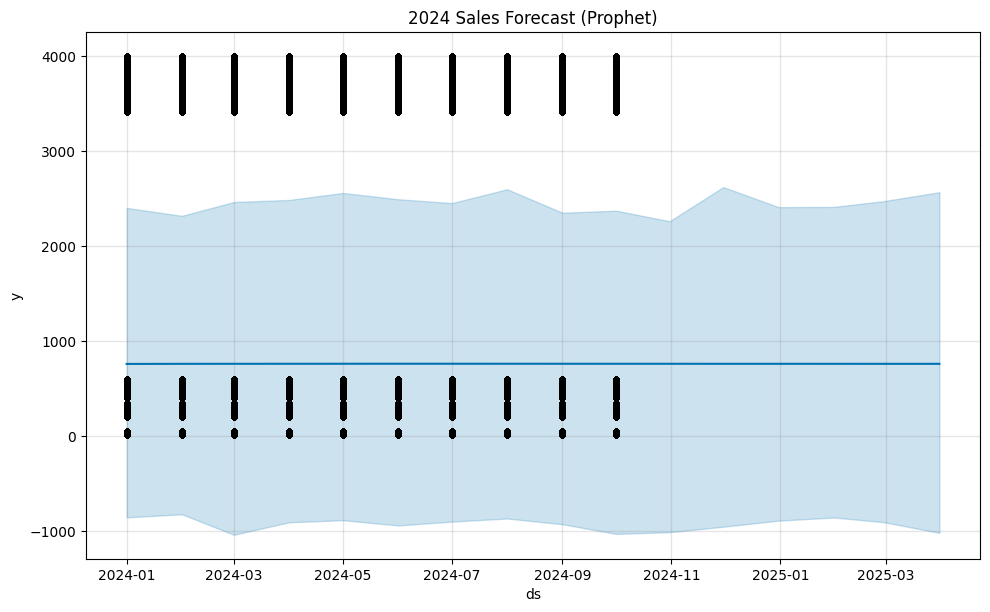

In [ ]:
from prophet import Prophet

# Prepare data for Prophet
# Use 'Month' instead of 'Date' and convert to datetime
df_prophet_2024 = df_2024[['Month', 'Monthly Sales']].rename(columns={'Month': 'ds', 'Monthly Sales': 'y'})
df_prophet_2024['ds'] = pd.to_datetime(df_prophet_2024['ds'], format='%d-%m-%Y', errors='coerce')


# Fit the model
model_2024 = Prophet()
model_2024.fit(df_prophet_2024)

# Print original data and forecasted data
print("Original Data:")
print(df_prophet_2024)

print("\nFuture Predictions:")
print(forecast_2024[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])  # Showing predicted values and confidence intervals

# Future predictions
future_2024 = model_2024.make_future_dataframe(periods=6, freq='M')
forecast_2024 = model_2024.predict(future_2024)

# Plot forecast
model_2024.plot(forecast_2024)
plt.title('2024 Sales Forecast (Prophet)')
plt.show()

**Handling of Seasonality and Anomalies:** Prophet effectively integrates seasonality and accommodates anomalies, producing predictions with confidence intervals that reflect potential variability in sales performance.

**Future Predictions with Broad Intervals:** The forecasted values (e.g., ~760 for 2024) come with wide confidence intervals (e.g., ranging from -1000 to 2500+). This highlights uncertainty in the data and external factors influencing variability.

**Steady Predicted Trend:** Despite historical data showing distinct seasonal spikes (e.g., 20 in early months and 446 mid-year), Prophet's forecasts remain relatively stable (~760) across months, suggesting it captures long-term trends while moderating extreme fluctuations.

**Conclusion:**

The Sales Analysis and Forecasting for Amazavr has demonstrated the value of a data-driven approach in optimizing inventory management, marketing strategies, and customer engagement. By leveraging historical sales data, understanding seasonal trends, and employing advanced forecasting models like SARIMA and Facebook Prophet, the project has provided actionable insights to enhance decision-making processes. The correlation analysis and feature engineering highlighted key relationships and patterns, aiding in the identification of top-performing product categories and areas for improvement. Overall, this project has shown the importance of integrating data insights into business operations for sustained growth and efficiency.

**Recommendations:**

* **Focus on Top-Selling Products:** Direct more marketing efforts and inventory towards the top 3 best-selling products to maximize their revenue potential. These products are key revenue drivers and warrant prioritization in promotional strategies.

* **Category-Level Insights:** Continuously monitor and analyze the performance of different product categories to understand their contribution to sales. This will help in making informed decisions regarding which categories to emphasize or de-emphasize based on market demand.

* **Optimize Inventory Management:** Use sales data to inform inventory levels, ensuring adequate stock to meet demand without incurring excess. Regularly review sales trends to adjust reorder levels and prevent stockouts or overstock situations.

* **Targeted Marketing Strategies:** Tailor marketing campaigns to promote high-performing categories and products. Leverage data-driven insights to design promotions that can stimulate sales in underperforming categories.

* **Regular Performance Reviews:**  Implement regular sales performance reviews to assess the impact of marketing campaigns and inventory decisions on sales. These reviews should be used to refine strategies based on actual performance data.

* **Scalability:** As Amazavr continues to grow, maintain a scalable sales performance analysis framework. This will ensure the ability to adapt to new data sources, changing sales trends, and the evolving business landscape.

* **Documentation and Continuous Improvement:** Keep detailed records of sales performance data and decisions made based on these insights. This documentation will be invaluable for ongoing analysis, allowing for continuous improvement in inventory and marketing strategies.